
# Sobel Edge Detection (Simple)

This minimal notebook loads (or generates) a grayscale image and applies **Sobel X**, **Sobel Y**, and a **combined** edge map using OpenCV.


In [2]:

import os
import numpy as np
import cv2
import matplotlib.pyplot as plt

print("OpenCV:", cv2.__version__)


OpenCV: 4.11.0


Image shape: (256, 384)


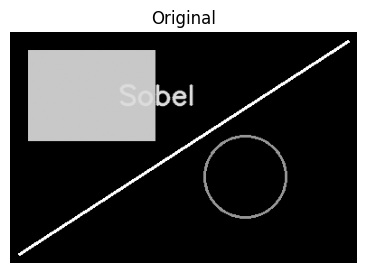

In [3]:

# Set this to your image file name if you have one in the same folder as the notebook
IMG_PATH = "example.jpg"

def make_synthetic(w=384, h=256):
    img = np.zeros((h, w), dtype=np.uint8)
    cv2.rectangle(img, (20, 20), (160, 120), 200, -1)
    cv2.circle(img, (260, 160), 45, 150, 2)
    cv2.line(img, (10, h-10), (w-10, 10), 255, 2)
    cv2.putText(img, "Sobel", (120, 80), cv2.FONT_HERSHEY_SIMPLEX, 1, 220, 2, cv2.LINE_AA)
    return img

if os.path.exists(IMG_PATH):
    img = cv2.imread(IMG_PATH, cv2.IMREAD_GRAYSCALE)
    if img is None:
        img = make_synthetic()
else:
    img = make_synthetic()

print("Image shape:", img.shape)
plt.figure(figsize=(5,3))
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')
plt.show()


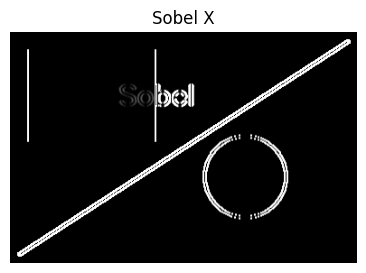

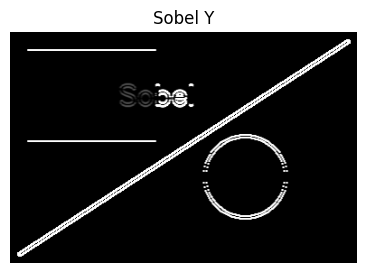

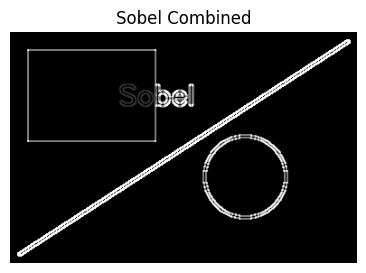

In [4]:

# Sobel parameters
KSIZE = 3

# Compute Sobel gradients
gx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=KSIZE)
gy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=KSIZE)

# Convert to 8-bit for display
gx_u8 = cv2.convertScaleAbs(gx)
gy_u8 = cv2.convertScaleAbs(gy)

# Combine
g_combined = cv2.addWeighted(gx_u8, 0.5, gy_u8, 0.5, 0)

# Show results (each on its own figure)
plt.figure(figsize=(5,3))
plt.imshow(gx_u8, cmap='gray')
plt.title('Sobel X')
plt.axis('off')
plt.show()

plt.figure(figsize=(5,3))
plt.imshow(gy_u8, cmap='gray')
plt.title('Sobel Y')
plt.axis('off')
plt.show()

plt.figure(figsize=(5,3))
plt.imshow(g_combined, cmap='gray')
plt.title('Sobel Combined')
plt.axis('off')
plt.show()
